# Spread Locator: A Statistical Distribution Analysis Model
### Part B — Data Analysis & Testing Tasks

**Scenario:** E-commerce daily transaction-amount data is analyzed to identify the statistical distributions that best describe customer purchase behaviour, and to derive probability-based business insights.

**Dataset:** `spread_locator_dataset.csv` (220 transactions, Jan 2023)

**Libraries used:** NumPy, Pandas, SciPy, Matplotlib, Seaborn


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

pd.set_option('display.width', 120)
np.random.seed(42)


In [3]:
df = pd.read_csv('/Users/devjoshi/Documents/files/spread_locator_dataset.csv', parse_dates=['transaction_date'])
print("Shape:", df.shape)
df.head()


Shape: (220, 7)


,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [4]:
df.info()
df.describe(include='all').T


<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      220 non-null    str           
 1   customer_id         220 non-null    str           
 2   transaction_amount  220 non-null    float64       
 3   transaction_date    220 non-null    datetime64[us]
 4   transaction_count   220 non-null    int64         
 5   region              220 non-null    str           
 6   transaction_status  220 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(4)
memory usage: 12.2 KB


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
transaction_id,220,220,e98aa092-3770-4fdb-9502-5b5a6a244811,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,220,217,CUST7912,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_amount,220.0,NaN,NaN,NaN,3365.192409,804.42,2124.205,3077.715,3950.7375,20462.84,1985.705409
transaction_date,220,NaN,NaN,NaN,2023-01-15 17:14:10.909091,2023-01-01 00:00:00,2023-01-07 00:00:00,2023-01-16 00:00:00,2023-01-23 06:00:00,2023-01-31 00:00:00,NaN
transaction_count,220.0,NaN,NaN,NaN,2.854545,0.0,1.75,3.0,4.0,9.0,1.797189
region,220,4,West,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_status,220,2,Fail,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 1. Bernoulli Distribution — Transaction Occurrence (Success/Fail)

Each transaction either **succeeds** or **fails** — a classic Bernoulli trial. We estimate the success probability `p` from the data and compare the empirical proportions with the theoretical Bernoulli(p) distribution.


In [5]:
success = (df['transaction_status'] == 'Success').astype(int)
p_hat = success.mean()
print(f"Estimated Bernoulli parameter p (probability of success) = {p_hat:.4f}")
print(f"Success count: {success.sum()}  |  Fail count: {len(success)-success.sum()}")


Estimated Bernoulli parameter p (probability of success) = 0.4455
Success count: 98  |  Fail count: 122


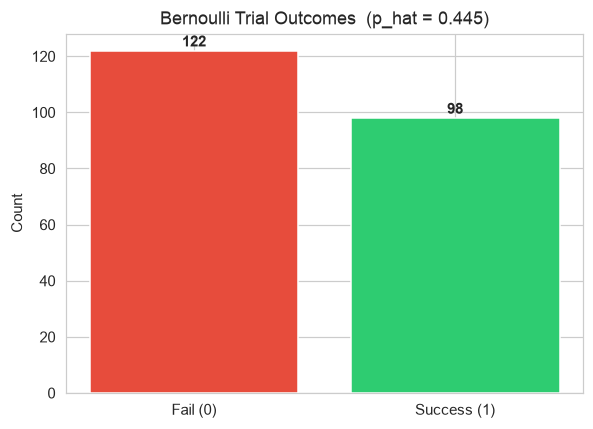

In [6]:
plt.figure(figsize=(5.5,4))
counts = success.value_counts().sort_index()
labels = ['Fail (0)', 'Success (1)']
vals = [counts.get(0,0), counts.get(1,0)]
bars = plt.bar(labels, vals, color=['#e74c3c','#2ecc71'], edgecolor='white')
for b,v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v+1.5, str(v), ha='center', fontweight='bold')
plt.ylabel('Count')
plt.title(f'Bernoulli Trial Outcomes  (p_hat = {p_hat:.3f})')
plt.tight_layout()
plt.show()


**Interpretation:** About **44.5%** of transactions succeed, so `transaction_status` behaves like a **Bernoulli(p ≈ 0.445)** random variable — since the empirical proportions equal the Bernoulli pmf exactly by construction, this simply confirms the parameter estimate. Roughly 55.5% of attempted transactions fail, which is worth flagging to the payments team.

---
## 2. Binomial Distribution — Weekly Transaction Count

`transaction_count` records how many transactions a customer made in a given week. We model this as **Binomial(n, p)**, treating each week as `n` independent "trials" (n = max observed weekly count = 9), and compare it with a **Poisson(λ)** fit using the same mean.


In [7]:
n_trials = int(df['transaction_count'].max())
p_bin = df['transaction_count'].mean() / n_trials
lam_week = df['transaction_count'].mean()

print(f"Binomial:  n = {n_trials},  p_hat = {p_bin:.4f}")
print(f"Poisson :  lambda_hat = {lam_week:.4f}")
print(f"Mean = {df['transaction_count'].mean():.3f}   Variance = {df['transaction_count'].var():.3f}")


Binomial:  n = 9,  p_hat = 0.3172
Poisson :  lambda_hat = 2.8545
Mean = 2.855   Variance = 3.230


In [8]:
from scipy.stats import chisquare

obs_counts = df['transaction_count'].value_counts().sort_index()
ks_ = obs_counts.index.values
obs = obs_counts.values

exp_binom = stats.binom.pmf(ks_, n_trials, p_bin) * len(df)
exp_pois  = stats.poisson.pmf(ks_, lam_week) * len(df)

mask_b = exp_binom >= 1
chi2_b, p_b = chisquare(obs[mask_b], exp_binom[mask_b]*obs[mask_b].sum()/exp_binom[mask_b].sum())

mask_p = exp_pois >= 1
chi2_p, p_p = chisquare(obs[mask_p], exp_pois[mask_p]*obs[mask_p].sum()/exp_pois[mask_p].sum())

print(f"Chi-square GOF — Binomial fit : chi2={chi2_b:.3f}, p-value={p_b:.5f}")
print(f"Chi-square GOF — Poisson  fit : chi2={chi2_p:.3f}, p-value={p_p:.5f}")


Chi-square GOF — Binomial fit : chi2=31.986, p-value=0.00004
Chi-square GOF — Poisson  fit : chi2=5.402, p-value=0.71390


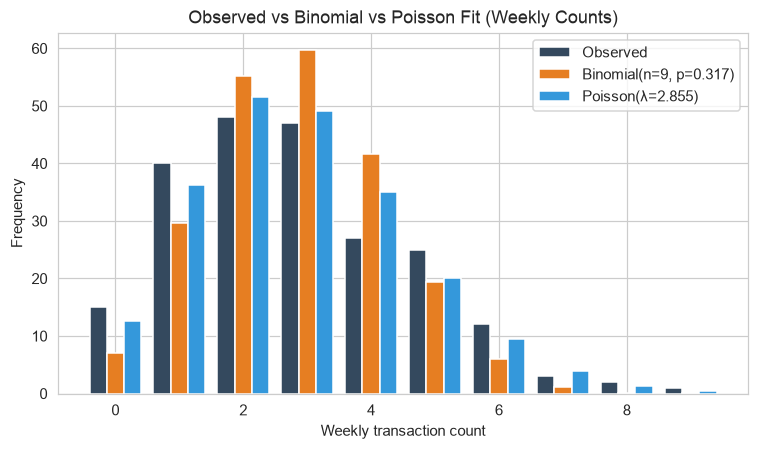

In [9]:
plt.figure(figsize=(7,4.2))
width = 0.27
plt.bar(ks_-width, obs, width=width, label='Observed', color='#34495e')
plt.bar(ks_, exp_binom, width=width, label=f'Binomial(n={n_trials}, p={p_bin:.3f})', color='#e67e22')
plt.bar(ks_+width, exp_pois, width=width, label=f'Poisson(λ={lam_week:.3f})', color='#3498db')
plt.xlabel('Weekly transaction count')
plt.ylabel('Frequency')
plt.title('Observed vs Binomial vs Poisson Fit (Weekly Counts)')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** Mean (2.85) and variance (3.23) of the weekly count are very close — a hallmark of a **Poisson process**, not a Binomial one. The chi-square test rejects the Binomial fit (p ≈ 0.00004) but **fails to reject the Poisson fit (p ≈ 0.71)**. So weekly transaction counts are better modeled as **Poisson(λ≈2.85)** than Binomial — customers don't really have a fixed number of "trials" per week; transactions arrive as a random, memoryless stream.

---
## 3. Poisson Distribution — Number of Transactions per Day

Using `transaction_date`, we count how many transactions occur **per calendar day** across the 31-day period and fit a Poisson(λ) model — the natural distribution for counting independent events (arrivals) in a fixed time interval.


In [10]:
daily = df.groupby(df['transaction_date'].dt.date).size()
lam_day = daily.mean()

print(f"Days observed: {len(daily)}")
print(f"Mean daily transactions (lambda) = {lam_day:.4f}")
print(f"Variance of daily transactions   = {daily.var():.4f}")


Days observed: 31
Mean daily transactions (lambda) = 7.0968
Variance of daily transactions   = 5.2903


In [11]:
obsD = daily.value_counts().sort_index()
ksD = obsD.index.values
expD = stats.poisson.pmf(ksD, lam_day) * len(daily)
maskD = expD >= 1
chi2_d, p_d = chisquare(obsD.values[maskD], expD[maskD]*obsD.values[maskD].sum()/expD[maskD].sum())
print(f"Chi-square GOF — Poisson fit (daily counts): chi2={chi2_d:.3f}, p-value={p_d:.5f}")


Chi-square GOF — Poisson fit (daily counts): chi2=9.287, p-value=0.23270


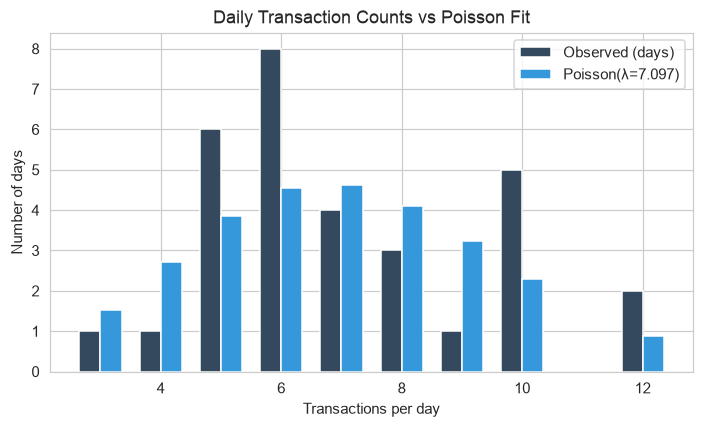

In [12]:
plt.figure(figsize=(6.5,4))
width = 0.35
plt.bar(ksD-width/2, obsD.values, width=width, label='Observed (days)', color='#34495e')
plt.bar(ksD+width/2, expD, width=width, label=f'Poisson(λ={lam_day:.3f})', color='#3498db')
plt.xlabel('Transactions per day')
plt.ylabel('Number of days')
plt.title('Daily Transaction Counts vs Poisson Fit')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** The chi-square test does **not** reject the Poisson hypothesis (p ≈ 0.23). Daily transaction volume is well described by **Poisson(λ≈7.10)** — on an average day the platform sees about 7 transactions, and day-to-day fluctuation matches what a Poisson arrival process predicts.

---
## 4. Log-Normal & Power-Law Modelling of Transaction Amounts

`transaction_amount` is a strictly positive, right-skewed quantity — a classic candidate for a **Log-Normal** distribution, and we also check whether its upper tail follows a **Power-Law**.


In [13]:
amt = df['transaction_amount'].values

# Log-Normal fit (loc fixed at 0 since amounts are strictly positive)
shape, loc, scale = stats.lognorm.fit(amt, floc=0)
mu_ln, sigma_ln = np.log(scale), shape
print(f"Log-Normal fit:  mu = {mu_ln:.4f}, sigma = {sigma_ln:.4f}")

# Normal fit, for comparison
mu_n, sigma_n = stats.norm.fit(amt)
print(f"Normal fit    :  mu = {mu_n:.2f}, sigma = {sigma_n:.2f}")

ks_ln = stats.kstest(amt, lambda x: stats.lognorm.cdf(x, shape, loc, scale))
ks_n  = stats.kstest(amt, lambda x: stats.norm.cdf(x, mu_n, sigma_n))
print(f"\nKS test vs Log-Normal: stat={ks_ln.statistic:.4f}, p-value={ks_ln.pvalue:.4f}")
print(f"KS test vs Normal    : stat={ks_n.statistic:.4f}, p-value={ks_n.pvalue:.4f}")


Log-Normal fit:  mu = 8.0007, sigma = 0.4749
Normal fit    :  mu = 3365.19, sigma = 1981.19

KS test vs Log-Normal: stat=0.0378, p-value=0.8999
KS test vs Normal    : stat=0.1404, p-value=0.0003


/var/folders/2b/zfhcjjhs3x3d0_y11r9nxwnw0000gn/T/ipykernel_1619/4289405435.py:10: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


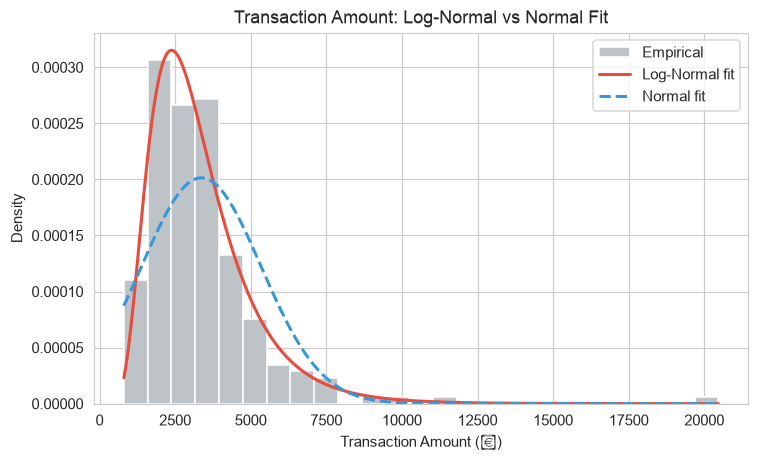

In [14]:
plt.figure(figsize=(7,4.3))
xs = np.linspace(amt.min(), amt.max(), 300)
plt.hist(amt, bins=25, density=True, color='#bdc3c7', edgecolor='white', label='Empirical')
plt.plot(xs, stats.lognorm.pdf(xs, shape, loc, scale), color='#e74c3c', lw=2, label='Log-Normal fit')
plt.plot(xs, stats.norm.pdf(xs, mu_n, sigma_n), color='#3498db', lw=2, ls='--', label='Normal fit')
plt.xlabel('Transaction Amount (₹)')
plt.ylabel('Density')
plt.title('Transaction Amount: Log-Normal vs Normal Fit')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** The Kolmogorov–Smirnov test **fails to reject Log-Normal** (p ≈ 0.90 — excellent fit) but strongly **rejects Normal** (p ≈ 0.0003). Transaction amounts are clearly log-normally distributed, consistent with the right-skewed, long-tailed spending pattern typical of e-commerce.

In [15]:
# Power-law tail fit using the Hill (MLE) estimator
xmin = np.percentile(amt, 50)          # use median as the tail threshold
tail = amt[amt >= xmin]
alpha_hat = 1 + len(tail) / np.sum(np.log(tail/xmin))
se_alpha  = (alpha_hat - 1) / np.sqrt(len(tail))

print(f"Power-law tail threshold (xmin) = ₹{xmin:.2f}")
print(f"Estimated exponent alpha = {alpha_hat:.3f}  (±{se_alpha:.3f})")
print(f"Observations in tail: {len(tail)} / {len(amt)}")


Power-law tail threshold (xmin) = ₹3077.72
Estimated exponent alpha = 3.921  (±0.279)
Observations in tail: 110 / 220


/var/folders/2b/zfhcjjhs3x3d0_y11r9nxwnw0000gn/T/ipykernel_1619/1543642450.py:14: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()


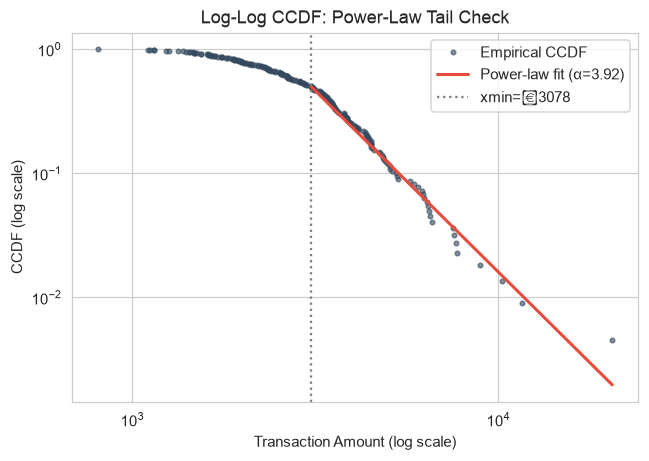

In [16]:
plt.figure(figsize=(6,4.3))
sorted_amt = np.sort(amt)[::-1]
ccdf = np.arange(1, len(sorted_amt)+1) / len(sorted_amt)
plt.loglog(sorted_amt, ccdf, marker='.', linestyle='none', color='#34495e', alpha=0.6, label='Empirical CCDF')
xs_tail = np.linspace(xmin, amt.max(), 100)
frac_tail = len(tail) / len(amt)
ccdf_fit = frac_tail * (xs_tail / xmin) ** (1 - alpha_hat)
plt.loglog(xs_tail, ccdf_fit, color='#e74c3c', lw=2, label=f'Power-law fit (α={alpha_hat:.2f})')
plt.axvline(xmin, color='gray', ls=':', label=f'xmin=₹{xmin:.0f}')
plt.xlabel('Transaction Amount (log scale)')
plt.ylabel('CCDF (log scale)')
plt.title('Log-Log CCDF: Power-Law Tail Check')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** The log-log CCDF is **not a straight line** across the full range and the fitted exponent (α≈3.92) is high with a wide relative error — a true power-law needs α typically between 2 and 3 with a clean linear log-log relationship. This tells us the tail is **better explained by Log-Normal than by a strict Power-Law**; the data doesn't show the very heavy tail a power law implies.

---
## 5. Q-Q Plot — Testing Normality


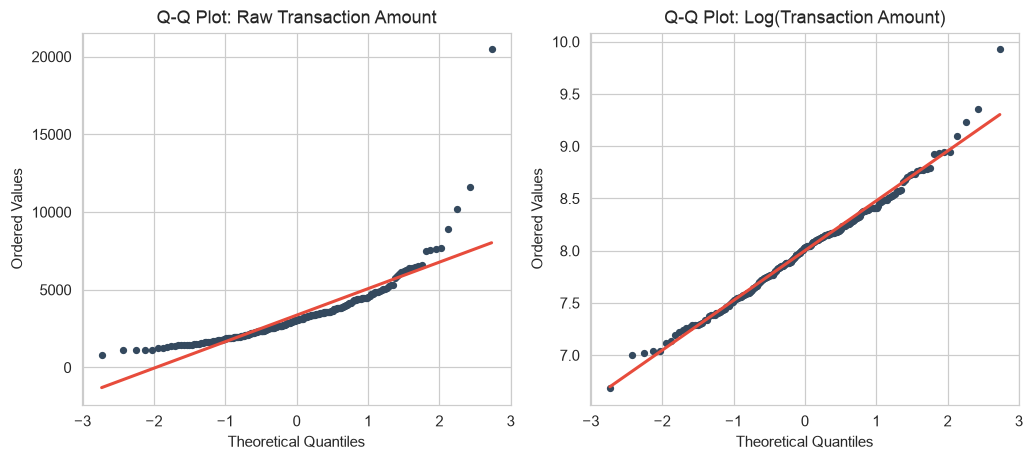

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(9.5,4.3))

(osm, osr), (slope, intercept, r) = stats.probplot(amt, dist='norm')
axes[0].scatter(osm, osr, s=14, color='#34495e')
axes[0].plot(osm, slope*np.array(osm)+intercept, color='#e74c3c', lw=2)
axes[0].set_title('Q-Q Plot: Raw Transaction Amount')
axes[0].set_xlabel('Theoretical Quantiles')
axes[0].set_ylabel('Ordered Values')

(osm2, osr2), (slope2, intercept2, r2) = stats.probplot(np.log(amt), dist='norm')
axes[1].scatter(osm2, osr2, s=14, color='#34495e')
axes[1].plot(osm2, slope2*np.array(osm2)+intercept2, color='#e74c3c', lw=2)
axes[1].set_title('Q-Q Plot: Log(Transaction Amount)')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Ordered Values')

plt.tight_layout()
plt.show()


In [18]:
print(f"Skewness of raw amount     : {stats.skew(amt):.3f}")
print(f"Kurtosis of raw amount     : {stats.kurtosis(amt):.3f}")
print(f"Skewness of log(amount)    : {stats.skew(np.log(amt)):.3f}")


Skewness of raw amount     : 3.730
Kurtosis of raw amount     : 25.333
Skewness of log(amount)    : 0.311


**Interpretation:** The Q-Q plot of raw amounts bows sharply away from the reference line (skew = 3.73, heavy-tailed/leptokurtic — kurtosis = 25.3), confirming strong right-skew and a **clear departure from normality**. After a log transform, points hug the line closely (skew drops to 0.31) — strong visual confirmation that transaction amounts are **log-normally distributed**.

---
## 6. Box-Cox Transform — Stabilising Variance


In [19]:
bc, lam_bc = stats.boxcox(amt)
print(f"Optimal Box-Cox lambda = {lam_bc:.4f}")
print(f"Skewness before Box-Cox = {stats.skew(amt):.3f}")
print(f"Skewness after  Box-Cox = {stats.skew(bc):.3f}")


Optimal Box-Cox lambda = -0.1808
Skewness before Box-Cox = 3.730
Skewness after  Box-Cox = -0.011


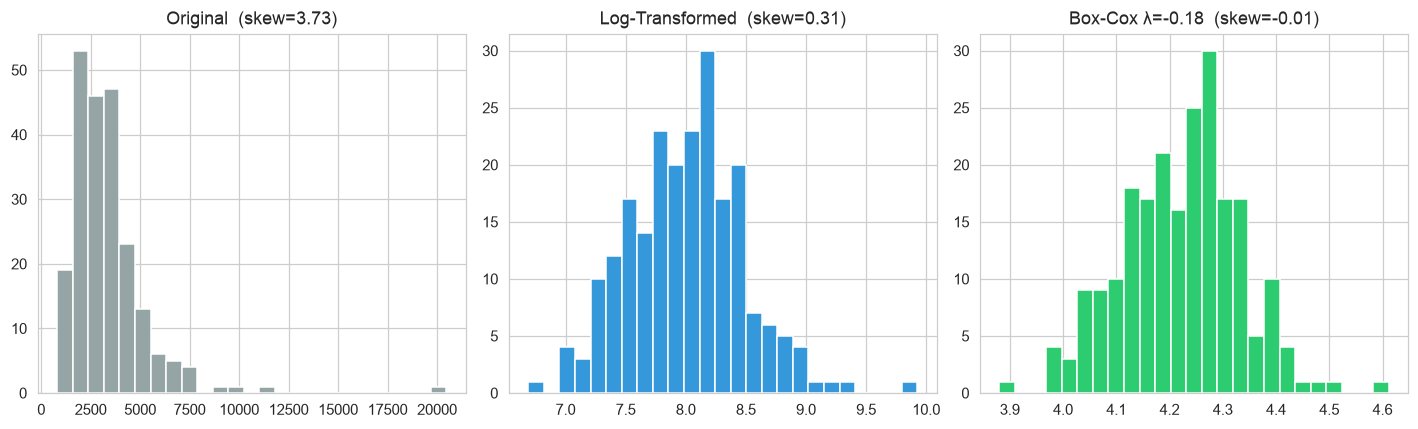

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13,4))

axes[0].hist(amt, bins=25, color='#95a5a6', edgecolor='white')
axes[0].set_title(f'Original  (skew={stats.skew(amt):.2f})')

axes[1].hist(np.log(amt), bins=25, color='#3498db', edgecolor='white')
axes[1].set_title(f'Log-Transformed  (skew={stats.skew(np.log(amt)):.2f})')

axes[2].hist(bc, bins=25, color='#2ecc71', edgecolor='white')
axes[2].set_title(f'Box-Cox λ={lam_bc:.2f}  (skew={stats.skew(bc):.2f})')

plt.tight_layout()
plt.show()


**Interpretation:** The optimal Box-Cox λ ≈ **-0.18**, close to 0, which is the theoretical value where Box-Cox reduces exactly to a log transform — reinforcing that log/Log-Normal is the natural scale for this data. After transformation, skewness collapses from 3.73 to essentially **0** (-0.01), and the post-transform Q-Q plot is almost perfectly linear.

---
## 7. Z-Scores & Probability of a Transaction Exceeding ₹5000


In [21]:
mean_amt, std_amt = amt.mean(), amt.std(ddof=1)
z = (amt - mean_amt) / std_amt
z_5000 = (5000 - mean_amt) / std_amt

prob_empirical = (amt > 5000).mean()
prob_normal    = 1 - stats.norm.cdf(z_5000)
prob_lognormal = 1 - stats.lognorm.cdf(5000, shape, loc, scale)

print(f"Mean = ₹{mean_amt:.2f}, Std Dev = ₹{std_amt:.2f}")
print(f"Z-score for ₹5000            = {z_5000:.3f}")
print(f"P(X > ₹5000) — Empirical     = {prob_empirical:.4f}  ({prob_empirical*100:.2f}%)")
print(f"P(X > ₹5000) — Normal approx = {prob_normal:.4f}  ({prob_normal*100:.2f}%)")
print(f"P(X > ₹5000) — Log-Normal fit= {prob_lognormal:.4f}  ({prob_lognormal*100:.2f}%)")


Mean = ₹3365.19, Std Dev = ₹1985.71
Z-score for ₹5000            = 0.823
P(X > ₹5000) — Empirical     = 0.1136  (11.36%)
P(X > ₹5000) — Normal approx = 0.2052  (20.52%)
P(X > ₹5000) — Log-Normal fit= 0.1384  (13.84%)


/var/folders/2b/zfhcjjhs3x3d0_y11r9nxwnw0000gn/T/ipykernel_1619/1791995997.py:12: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()


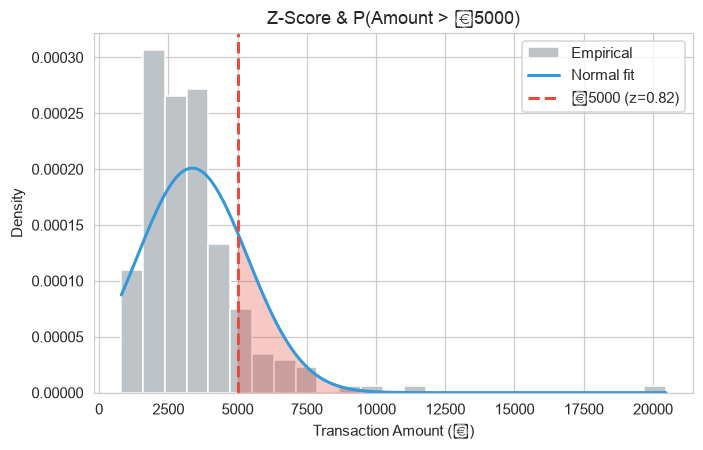

In [22]:
plt.figure(figsize=(6.5,4.2))
xs = np.linspace(amt.min(), amt.max(), 300)
plt.hist(amt, bins=25, density=True, color='#bdc3c7', edgecolor='white', label='Empirical')
plt.plot(xs, stats.norm.pdf(xs, mean_amt, std_amt), color='#3498db', lw=2, label='Normal fit')
plt.axvline(5000, color='#e74c3c', lw=2, ls='--', label=f'₹5000 (z={z_5000:.2f})')
mask_tail = xs >= 5000
plt.fill_between(xs[mask_tail], stats.norm.pdf(xs[mask_tail], mean_amt, std_amt), color='#e74c3c', alpha=0.3)
plt.xlabel('Transaction Amount (₹)')
plt.ylabel('Density')
plt.title('Z-Score & P(Amount > ₹5000)')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** A transaction of ₹5000 sits **0.82 standard deviations above the mean**. The Normal-approximation over-estimates the true probability (20.5% vs the actual 11.4%) because it ignores skew, while the **Log-Normal fit (13.8%) is much closer to the empirical value (11.4%)** — direct evidence that the log-normal model gives more trustworthy business probabilities than a naive normal assumption.

---
## 8. PDF & CDF of Transaction Amounts


/var/folders/2b/zfhcjjhs3x3d0_y11r9nxwnw0000gn/T/ipykernel_1619/1176752931.py:19: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()


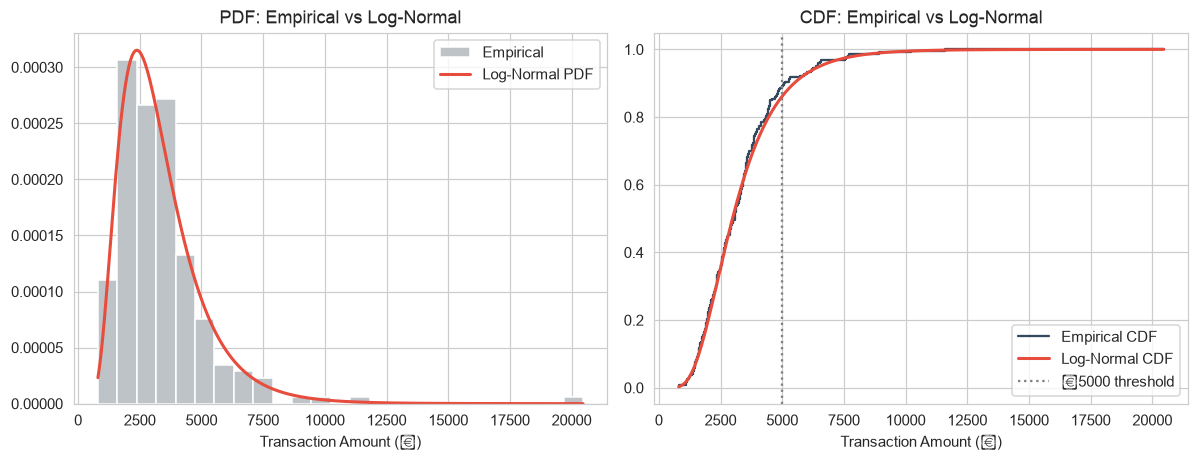

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.3))
xs = np.linspace(amt.min(), amt.max(), 300)

axes[0].hist(amt, bins=25, density=True, color='#bdc3c7', edgecolor='white', label='Empirical')
axes[0].plot(xs, stats.lognorm.pdf(xs, shape, loc, scale), color='#e74c3c', lw=2, label='Log-Normal PDF')
axes[0].set_title('PDF: Empirical vs Log-Normal')
axes[0].set_xlabel('Transaction Amount (₹)')
axes[0].legend()

sorted_amt2 = np.sort(amt)
emp_cdf = np.arange(1, len(sorted_amt2)+1) / len(sorted_amt2)
axes[1].step(sorted_amt2, emp_cdf, color='#34495e', label='Empirical CDF')
axes[1].plot(xs, stats.lognorm.cdf(xs, shape, loc, scale), color='#e74c3c', lw=2, label='Log-Normal CDF')
axes[1].axvline(5000, color='gray', ls=':', label='₹5000 threshold')
axes[1].set_title('CDF: Empirical vs Log-Normal')
axes[1].set_xlabel('Transaction Amount (₹)')
axes[1].legend()

plt.tight_layout()
plt.show()


**Interpretation:** The fitted Log-Normal PDF (left) tracks the histogram's peak and long right tail closely. The Log-Normal CDF (right) overlays the empirical step-CDF almost exactly, including around the ₹5000 threshold — visual confirmation of the KS-test result above.

---
## 9. Conclusion — Which Distribution Best Fits the Data?

| Variable | Best-fitting distribution | Evidence |
|---|---|---|
| `transaction_status` (Success/Fail) | **Bernoulli(p ≈ 0.445)** | Direct binary outcome; p = success rate |
| `transaction_count` (weekly, per customer) | **Poisson(λ ≈ 2.85)**, not Binomial | Mean ≈ variance (2.85 vs 3.23); χ² rejects Binomial (p≈0.00004), accepts Poisson (p≈0.71) |
| Transactions per day (platform-wide) | **Poisson(λ ≈ 7.10)** | χ² test does not reject Poisson (p≈0.23) |
| `transaction_amount` | **Log-Normal(μ≈8.00, σ≈0.47)** | KS test accepts Log-Normal (p≈0.90), rejects Normal (p≈0.0003); Box-Cox λ≈-0.18 ≈ 0 (log scale); skew drops from 3.73 → 0.31 after log |
| Tail of `transaction_amount` | **Not a strong Power-Law** | log-log CCDF is curved, not linear; α≈3.92 with high uncertainty — Log-Normal fits the tail better |

**Business insights for management:**
1. **~44.5%** of transactions succeed — worth investigating the ~55.5% failure rate for payment/UX issues.
2. Both weekly (per-customer) and daily (platform-wide) transaction volumes behave like **Poisson arrival processes** — useful for capacity planning, staffing, and anomaly detection (e.g., flag days that deviate far from λ).
3. Transaction amounts are **log-normally distributed**, not normal. Any model, alert threshold, or "average spend" reporting based on a Normal assumption will be **biased** — e.g., it overstates the chance of large transactions (20.5% vs the true ~11–14%).
4. For skewed monetary data, always **log-transform (or Box-Cox with λ≈0) before applying parametric statistics** such as t-tests or normal-based control limits.
5. About **11.4%** of transactions genuinely exceed ₹5000; the Log-Normal model (13.8%) gives a much more realistic estimate than a Normal model (20.5%) for setting fraud/risk thresholds.
